# NB5.3: Matriz Fundamental, Geometria Epipolar e Decomposição da Matriz Essencial

## Objetivos de Aprendizagem

Neste notebook, o estudante:

- Estima a matriz fundamental ($F$) a partir de correspondências calibradas entre dois fotogramas
- Verifica a restrição epipolar algebraicamente e a visualiza sobre as imagens
- Decompõe a matriz essencial ($E$) em rotação ($R$) e translação ($t$) utilizando SVD
- Aplica o teste de quiralidade para identificar a solução geometricamente válida
- Analisa casos degenerados (rotação pura, cena planar)

Este notebook constrói sobre os fundamentos de **NB5.1** (matriz de intrinsecas $K$ e calibração de câmara) e **NB5.2** (correspondências de pontos entre imagens).

---

[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppestana-supervisor/ComputerVision/blob/main/NB5.3_epipolar_geometry.ipynb)

> **Nota importante**
>
> Este notebook é carregado diretamente a partir do repositório oficial no GitHub e é apenas para **leitura**.  
> As alterações **não ficam guardadas**.
>
> Para guardar uma versão pessoal:
> - No Colab, ir a **Ficheiro → Guardar uma cópia no Drive**.  
> - A cópia ficará disponível em `O meu Drive / Colab Notebooks`.
>
> Para colaboração:
> - Abrir a versão pessoal no Google Drive.  
> - Clicar em **Partilhar** → **Qualquer pessoa com o link pode editar** (ou adicionar os colegas manualmente).  
> - A partir daí, todos podem editar em tempo real, como num Google Docs.
>
> Para guardar resultados (imagens, ficheiros, etc.) no  Drive:
> ```python
> from google.colab import drive
> drive.mount('/content/drive')
> ```
> Depois gravar, por exemplo, em:
> ```python
> img.save('/content/drive/MyDrive/PDI_outputs/resultado.png')
> ```

In [ ]:
### !!! Executar esta célula primeiro, se dentro do Colab
# Clona o repositório completo para garantir acesso aos dados/imagens.

from pathlib import Path
import os

repo_dir = Path("/content/ComputerVision")

if not repo_dir.exists():
    !git clone https://github.com/ppestana-supervisor/ComputerVision.git {repo_dir}

os.chdir(repo_dir)
print("Diretório atual:", os.getcwd())
print("Conteúdo:", os.listdir("."))

In [1]:
import cv2
import numpy as np
from scipy import linalg
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from pathlib import Path
from skimage import data, color
from skimage.util import img_as_ubyte
import warnings
warnings.filterwarnings('ignore')

## Fase 1: Carregar Par Estéreo Calibrado e Correspondências

Carregamos um par de imagens estéreo capturadas com a mesma câmara e com matriz de intrinsecas conhecida ($K$). A normalização das coordenadas de imagem é crucial para a estabilidade numérica: isto é um princípio fundamental em Hartley & Zisserman.

Se $K$ não estiver disponível (porque este notebook é executado isoladamente), geramos um $K$ plausível baseado nas dimensões da imagem. Na prática, $K$ deve provir de **NB5.1** (calibração).

In [2]:
data_dir = Path('data')
data_dir.mkdir(exist_ok=True)
img1_path = data_dir / 'stereo_left.png'
img2_path = data_dir / 'stereo_right.png'
K_path = data_dir / 'K.npy'
correspondences_path = data_dir / 'correspondences.npz'
# ============================================================
# Carregamento das imagens estéreo
# ============================================================
if img1_path.exists() and img2_path.exists():
    img1 = cv2.imread(str(img1_path), cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(str(img2_path), cv2.IMREAD_GRAYSCALE)
    if img1 is None or img2 is None:
        raise RuntimeError("Os ficheiros de imagem existem mas não puderam ser lidos.")
    print(f"Imagens carregadas de ficheiro: {img1.shape}")
else:
    img_L_rgb, img_R_rgb, disp = data.stereo_motorcycle()
    img1 = img_as_ubyte(color.rgb2gray(img_L_rgb))
    img2 = img_as_ubyte(color.rgb2gray(img_R_rgb))
    print(f"Imagens carregadas do dataset stereo_motorcycle: {img1.shape}")
# ============================================================
# Carregamento (ou aproximação) da matriz intrínseca
# ============================================================
if K_path.exists():
    K = np.load(str(K_path))
    print(f"Matriz intrínseca K carregada:\n{K}")
else:
    H, W = img1.shape
    # Aproximação didática simples:
    # assume distância focal aproximadamente igual à maior dimensão da imagem
    f = float(max(W, H))
    cx = W / 2.0
    cy = H / 2.0
    K = np.array([
        [f, 0, cx],
        [0, f, cy],
        [0, 0, 1]
    ], dtype=np.float64)
    print("Aviso: não foi encontrada uma matriz de calibração real (K.npy).")
    print("Foi gerada uma matriz intrínseca aproximada apenas para fins didáticos.")
    print(f"K aproximada:\n{K}")

Imagens carregadas do dataset stereo_motorcycle: (500, 741)
Aviso: não foi encontrada uma matriz de calibração real (K.npy).
Foi gerada uma matriz intrínseca aproximada apenas para fins didáticos.
K aproximada:
[[741.    0.  370.5]
 [  0.  741.  250. ]
 [  0.    0.    1. ]]


## Fase 2: Correspondências de Pontos

Carregamos ou computamos correspondências entre as duas imagens. Se um arquivo `.npz` com correspondências pré-computadas estiver disponível, usamo-lo. Caso contrário, detectamos pontos-chave utilizando SIFT e estabelecemos correspondências através de matching de descritores.

In [3]:
if correspondences_path.exists():
    loaded = np.load(str(correspondences_path))
    pts1 = loaded['pts1']
    pts2 = loaded['pts2']
    print(f"Correspondências carregadas: {len(pts1)} pares")

else:
    sift = cv2.SIFT_create()

    kp1, des1 = sift.detectAndCompute(img1, None)
    kp2, des2 = sift.detectAndCompute(img2, None)

    if des1 is None or des2 is None:
        raise RuntimeError("Não foram encontrados descritores SIFT suficientes numa das imagens.")

    bf = cv2.BFMatcher(cv2.NORM_L2)

    knn_matches = bf.knnMatch(des1, des2, k=2)

    good_matches = []
    ratio = 0.75

    for pair in knn_matches:
        if len(pair) == 2:
            m, n = pair
            if m.distance < ratio * n.distance:
                good_matches.append(m)

    if len(good_matches) < 8:
        raise RuntimeError(
            f"Foram encontradas apenas {len(good_matches)} correspondências válidas. "
            "São necessárias pelo menos 8 para estimar a matriz fundamental."
        )

    pts1 = np.float32([kp1[m.queryIdx].pt for m in good_matches])
    pts2 = np.float32([kp2[m.trainIdx].pt for m in good_matches])

    print(f"Keypoints detectados: img1={len(kp1)}, img2={len(kp2)}")
    print(f"Correspondências após ratio test ({ratio}): {len(pts1)} pares")

print(
    f"Intervalo de coordenadas img1: "
    f"x=[{pts1[:, 0].min():.1f}, {pts1[:, 0].max():.1f}], "
    f"y=[{pts1[:, 1].min():.1f}, {pts1[:, 1].max():.1f}]"
)

print(
    f"Intervalo de coordenadas img2: "
    f"x=[{pts2[:, 0].min():.1f}, {pts2[:, 0].max():.1f}], "
    f"y=[{pts2[:, 1].min():.1f}, {pts2[:, 1].max():.1f}]"
)

Keypoints detectados: img1=2618, img2=2612
Correspondências após ratio test (0.75): 996 pares
Intervalo de coordenadas img1: x=[13.5, 732.9], y=[3.2, 476.4]
Intervalo de coordenadas img2: x=[4.4, 714.0], y=[3.0, 475.4]


## Fase 3: Normalização de Coordenadas de Imagem

A normalização é fundamental para a estabilidade numérica do algoritmo de estimação de $F$.

Transformamos coordenadas de imagem $\mathbf{x}$ (em pixels) para coordenadas normalizadas $\mathbf{x}_{\text{norm}}$ através da matriz de intrinsecas inversa:

$$\mathbf{x}_{\text{norm}} = K^{-1} \mathbf{x}$$

onde $\mathbf{x}$ é representado em coordenadas homogéneas $[x, y, 1]^T$.

Geometricamente, esta operação projeta os pontos de imagem no plano focal normativo (onde $f=1$), removendo os efeitos da escala focal e da posição do ponto principal. Isto reduz a variância numérica e melhora a condição da matriz de design no algoritmo do $8$-ponto.

In [4]:
K_inv = np.linalg.inv(K)

pts1_hom = np.vstack([pts1.T, np.ones(len(pts1))])
pts1_norm_hom = K_inv @ pts1_hom
pts1_norm = (pts1_norm_hom[:2] / pts1_norm_hom[2]).T

pts2_hom = np.vstack([pts2.T, np.ones(len(pts2))])
pts2_norm_hom = K_inv @ pts2_hom
pts2_norm = (pts2_norm_hom[:2] / pts2_norm_hom[2]).T

print(f"Coordenadas pseudo-normalizadas (via K aproximada) img1: x=[{pts1_norm[:, 0].min():.3f}, {pts1_norm[:, 0].max():.3f}], y=[{pts1_norm[:, 1].min():.3f}, {pts1_norm[:, 1].max():.3f}]")
print(f"Coordenadas pseudo-normalizadas (via K aproximada) img2: x=[{pts2_norm[:, 0].min():.3f}, {pts2_norm[:, 0].max():.3f}], y=[{pts2_norm[:, 1].min():.3f}, {pts2_norm[:, 1].max():.3f}]")

Coordenadas pseudo-normalizadas (via K aproximada) img1: x=[-0.482, 0.489], y=[-0.333, 0.306]
Coordenadas pseudo-normalizadas (via K aproximada) img2: x=[-0.494, 0.464], y=[-0.333, 0.304]


## Fase 4: Estimação da Matriz Fundamental com RANSAC

A matriz fundamental $F$ codifica a geometria epipolar entre dois fotogramas. Para todo par de pontos correspondentes $\mathbf{x}_1$ (na primeira imagem) e $\mathbf{x}_2$ (na segunda imagem), o ponto $\mathbf{x}_2$ deve satisfazer a **restrição epipolar**:

$$\mathbf{x}_2^T F \mathbf{x}_1 = 0$$

Utilizamos o algoritmo do 8-ponto (normalizado) com RANSAC para estimar $F$ robustamente. O RANSAC rejeita correspondências que não cumprem a geometria epipolar (outliers causados por erros de matching ou oclusões).

Após a estimação, aplicamos a restrição de rank-2 a $F$ (exigida pela geometria epipolar) através da decomposição em valores singulares.

In [5]:
F, inlier_mask = cv2.findFundamentalMat(
    pts1, pts2,
    method=cv2.FM_RANSAC,
    ransacReprojThreshold=1.0,  # em píxeis
    confidence=0.99
)

if F is None or inlier_mask is None:
    raise RuntimeError("A estimação da matriz fundamental falhou.")

inlier_mask = inlier_mask.ravel().astype(bool)

num_inliers = np.sum(inlier_mask)
num_outliers = len(pts1) - num_inliers

print("Estimação da matriz fundamental F com RANSAC:")
print(f"  Inliers: {num_inliers} ({100*num_inliers/len(pts1):.1f}%)")
print(f"  Outliers: {num_outliers}")
print(f"\nMatriz fundamental F:\n{F}")

pts1_inliers = pts1[inlier_mask]
pts2_inliers = pts2[inlier_mask]
print(f"Pares mantidos para os passos seguintes: {len(pts1_inliers)}")

Estimação da matriz fundamental F com RANSAC:
  Inliers: 900 (90.4%)
  Outliers: 96

Matriz fundamental F:
[[-2.97757795e-07 -8.93792884e-04  1.67449265e-01]
 [ 8.59467968e-04  1.00502868e-05 -6.21093186e+00]
 [-1.58551519e-01  6.18809573e+00  1.00000000e+00]]
Pares mantidos para os passos seguintes: 900


## Fase 5: Aplicar Restrição de Rank-2 a F

Algebricamente, a matriz fundamental deve ter rank exatamente 2. Isto decorre do facto de que $F$ representa um mapa linear entre linhas epipolares em duas imagens, e o epipolo (ponto de fuga em cada imagem) deve estar numa reta com rank deficiente.

Utilizamos a decomposição em valores singulares (SVD) para enforçar esta restrição:

$$F = U S V^T$$

Tornamos zero o terceiro valor singular (o menor) para obter uma matriz rank-2:

$$F_{\text{rank-2}} = U \, \text{diag}(\sigma_1, \sigma_2, 0) \, V^T$$

In [6]:
U, S, Vt = linalg.svd(F)

print(f"Valores singulares de F (antes): {S}")
print(f"Razão σ1/σ3 = {S[0]/S[2]:.1f} (deve ser grande)")

S_rank2 = S.copy()
S_rank2[2] = 0
F = U @ np.diag(S_rank2) @ Vt

U, S, Vt = linalg.svd(F)
print(f"Valores singulares de F (após enforçar rank-2): {S}")

Valores singulares de F (antes): [6.72190833e+00 5.72165457e+00 7.80023987e-17]
Razão σ1/σ3 = 86175661892313344.0 (deve ser grande)
Valores singulares de F (após enforçar rank-2): [6.72190833e+00 5.72165457e+00 6.06997395e-17]


## Fase 6: Verificação da Restrição Epipolar (Teste Algébrico)

Para cada par de correspondências inlier $(\mathbf{x}_1, \mathbf{x}_2)$, computamos o escalar:

$$\varepsilon = \mathbf{x}_2^T F \mathbf{x}_1$$

Se a estimação de $F$ for precisa, $\varepsilon$ deve ser próximo a zero para todos os inliers. Reportamos a média e desvio padrão de $|\varepsilon|$ para todas as correspondências.

In [7]:
lines2 = cv2.computeCorrespondEpilines(
    pts1_inliers.reshape(-1, 1, 2),
    1,
    F
).reshape(-1, 3)

a = lines2[:, 0]
b = lines2[:, 1]
c = lines2[:, 2]

x2 = pts2_inliers[:, 0]
y2 = pts2_inliers[:, 1]

distances = np.abs(a*x2 + b*y2 + c) / np.sqrt(a*a + b*b)

print("Distância ponto–reta epipolar na imagem 2:")
print(f"  Média: {np.mean(distances):.3f} px")
print(f"  Desvio padrão: {np.std(distances):.3f} px")
print(f"  Máximo: {np.max(distances):.3f} px")

Distância ponto–reta epipolar na imagem 2:
  Média: 0.257 px
  Desvio padrão: 0.217 px
  Máximo: 0.995 px


## Fase 7: Visualização de Linhas Epipolares

A linha epipolar correspondente a um ponto $\mathbf{x}_1$ na primeira imagem é uma reta na segunda imagem, dada por:

$$\mathbf{l}_2 = F \mathbf{x}_1$$

A equação da reta é $l_1 x + l_2 y + l_3 = 0$.

Geometricamente, a linha epipolar contém todos os pontos 3D que se projetam em $\mathbf{x}_1$ na primeira câmara. O ponto correspondente $\mathbf{x}_2$ deve estar nesta reta.

Abaixo, selecionamos 10 correspondências inlier aleatórias e desenhamos as respectivas linhas epipolares sobre a segunda imagem, sobrepondo o ponto correspondente para verificação visual.

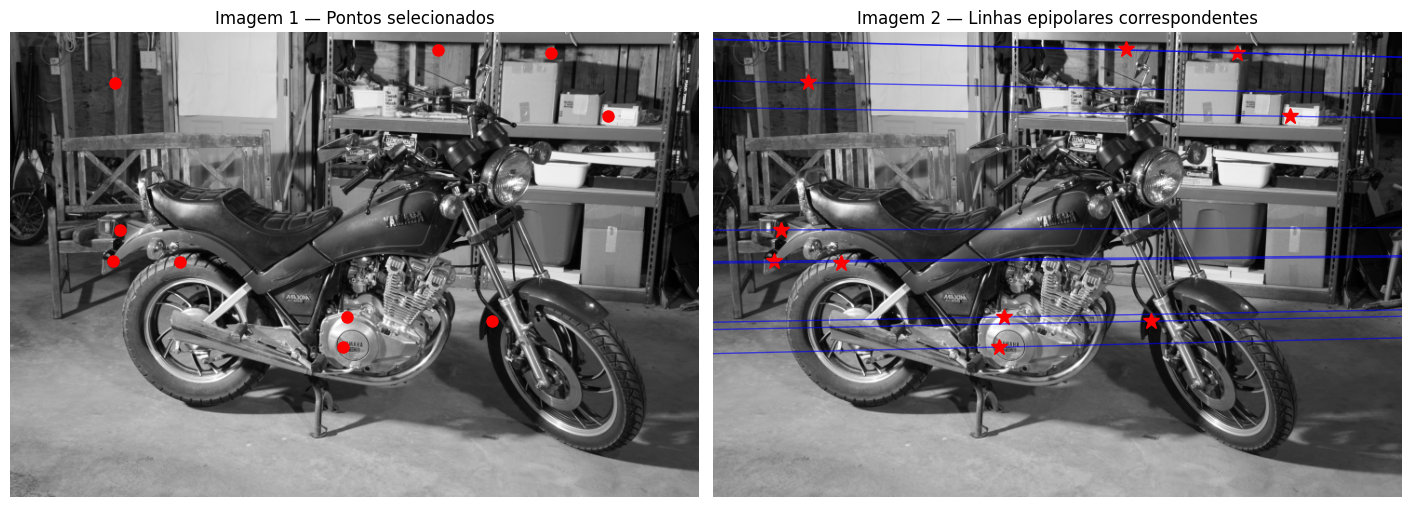

Linhas epipolares visualizadas para 10 correspondências.
Os pontos vermelhos na imagem 2 devem estar próximos das linhas azuis.


In [8]:
# Garantir que os inliers estão em coordenadas de píxel,
# coerentes com a matriz fundamental F estimada em píxeis.
pts1_inliers = pts1[inlier_mask]
pts2_inliers = pts2[inlier_mask]

num_lines = min(10, len(pts1_inliers))

rng = np.random.default_rng(42)
random_indices = rng.choice(len(pts1_inliers), num_lines, replace=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

ax1.imshow(img1, cmap='gray')
ax1.set_title('Imagem 1 — Pontos selecionados')

for idx in random_indices:
    x, y = pts1_inliers[idx]
    ax1.plot(x, y, 'ro', markersize=8)

ax1.set_xlim([0, img1.shape[1]])
ax1.set_ylim([img1.shape[0], 0])
ax1.axis('off')

ax2.imshow(img2, cmap='gray')
ax2.set_title('Imagem 2 — Linhas epipolares correspondentes')

for idx in random_indices:
    x1, y1 = pts1_inliers[idx]
    x2, y2 = pts2_inliers[idx]

    l2 = F @ np.array([x1, y1, 1.0])
    a, b, c = l2

    if abs(b) > 1e-8:
        x_start = 0
        y_start = -(a * x_start + c) / b
        x_end = img2.shape[1]
        y_end = -(a * x_end + c) / b
    elif abs(a) > 1e-8:
        y_start = 0
        x_start = -c / a
        y_end = img2.shape[0]
        x_end = -c / a
    else:
        continue

    ax2.plot([x_start, x_end], [y_start, y_end], 'b-', linewidth=1, alpha=0.6)
    ax2.plot(x2, y2, 'r*', markersize=12)

ax2.set_xlim([0, img2.shape[1]])
ax2.set_ylim([img2.shape[0], 0])
ax2.axis('off')

plt.show()

print(f"Linhas epipolares visualizadas para {num_lines} correspondências.")
print("Os pontos vermelhos na imagem 2 devem estar próximos das linhas azuis.")

## Fase 8: Matriz Essencial e Decomposição em Rotação e Translação

A matriz essencial $E$ é uma versão da matriz fundamental que incorpóra a calibração da câmara. É definida como:

$$E = K^T F K$$

A matriz essencial satisfaz uma estrutura específica. Através da decomposição em valores singulares:

$$E = U \Sigma V^T$$

onde $\Sigma = \text{diag}(1, 1, 0)$ (com valores singulares normalizados), podemos recuperar a rotação e translação.

Hartley & Zisserman demonstram que existem exatamente **quatro soluções candidatas** para $(R, t)$:

\begin{align}
R_1 &= U W V^T, & t_1 &= U_3 \\
R_2 &= U W^T V^T, & t_2 &= U_3 \\
R_3 &= U W V^T, & t_3 &= -U_3 \\
R_4 &= U W^T V^T, & t_4 &= -U_3
\end{align}

onde $U_3$ é a terceira coluna de $U$, e

$$W = \begin{bmatrix} 0 & -1 & 0 \\ 1 & 0 & 0 \\ 0 & 0 & 1 \end{bmatrix}$$

Apenas uma destas soluções é geometricamente válida: aquela em que pontos 3D triangulados ficam **em frente de ambas as câmaras** (profundidade positiva em ambas).

In [9]:
E = K.T @ F @ K

U, S, Vt = linalg.svd(E)

print(f"Matriz essencial E:\n{E}")
print(f"\nValores singulares de E: {S}")
print(f"Razão σ1/σ2 = {S[0]/S[1]:.4f}")
print(f"Razão σ3/σ2 = {S[2]/S[1]:.2e}")
print("\nPara uma matriz essencial ideal:")
print("  σ1 e σ2 devem ser iguais;")
print("  σ3 deve ser próximo de zero.")

Matriz essencial E:
[[-1.63493148e-01 -4.90764691e+02 -4.15769732e+01]
 [ 4.71917531e+02  5.51842154e+00 -4.36447993e+03]
 [ 4.16480191e+01  4.34185841e+03 -4.00449379e+00]]

Valores singulares de E: [4.39112569e+03 4.36869551e+03 6.47850087e-14]
Razão σ1/σ2 = 1.0051
Razão σ3/σ2 = 1.48e-17

Para uma matriz essencial ideal:
  σ1 e σ2 devem ser iguais;
  σ3 deve ser próximo de zero.


In [10]:
# Decomposição manual da matriz essencial em quatro hipóteses de pose relativa

W = np.array([
    [0, -1, 0],
    [1,  0, 0],
    [0,  0, 1]
], dtype=np.float64)

U, S, Vt = linalg.svd(E)

# Correção de sinal: garantir que U e Vt representam rotações próprias
if np.linalg.det(U) < 0:
    U[:, -1] *= -1

if np.linalg.det(Vt) < 0:
    Vt[-1, :] *= -1

R_a = U @ W @ Vt
R_b = U @ W.T @ Vt
t = U[:, 2]

# Correção adicional: garantir det(R)=+1
if np.linalg.det(R_a) < 0:
    R_a *= -1

if np.linalg.det(R_b) < 0:
    R_b *= -1

pose_candidates = [
    (R_a,  t),
    (R_a, -t),
    (R_b,  t),
    (R_b, -t),
]

print("Quatro soluções candidatas (R, t) computadas.")

for i, (R, t_candidate) in enumerate(pose_candidates, 1):
    det_R = np.linalg.det(R)

    print(f"\nSolução {i}:")
    print(f"  det(R) = {det_R:.6f}")
    print(
        f"  t = [{t_candidate[0]:.6f}, "
        f"{t_candidate[1]:.6f}, "
        f"{t_candidate[2]:.6f}]"
    )

Quatro soluções candidatas (R, t) computadas.

Solução 1:
  det(R) = 1.000000
  t = [0.993626, -0.009569, 0.112323]

Solução 2:
  det(R) = 1.000000
  t = [-0.993626, 0.009569, -0.112323]

Solução 3:
  det(R) = 1.000000
  t = [0.993626, -0.009569, 0.112323]

Solução 4:
  det(R) = 1.000000
  t = [-0.993626, 0.009569, -0.112323]


## Fase 9: Teste de Quiralidade: Seleção da Solução Válida

Para cada uma das quatro soluções candidatas, realizamos uma **triangulação**: projetamos pontos 3D através de ambas as câmaras e verificamos se a profundidade é positiva (ponto em frente da câmara).

A câmara 1 tem pose canónica: $P_1 = K [I | 0]$.
A câmara 2 tem pose: $P_2 = K [R | t]$.

Para cada par de correspondências, triangulamos o ponto 3D $\mathbf{X}$ e verificamos:
- Profundidade na câmara 1: $Z_1 = \mathbf{X}_z$ (coordenada z)
- Profundidade na câmara 2: $Z_2 = R_3 \cdot \mathbf{X} + t_3$ (coordenada z transformada)

A solução válida é aquela com o máximo número de pontos com $Z_1 > 0$ e $Z_2 > 0$.

In [11]:
def count_points_in_front(pts1_px, pts2_px, K, R, t, sample_size=50):
    rng = np.random.default_rng(42)
    sample_indices = rng.choice(
        len(pts1_px),
        min(sample_size, len(pts1_px)),
        replace=False
    )

    pts1_sample = pts1_px[sample_indices]
    pts2_sample = pts2_px[sample_indices]

    P1 = K @ np.hstack([np.eye(3), np.zeros((3, 1))])
    P2 = K @ np.hstack([R, t.reshape(3, 1)])

    X_hom = cv2.triangulatePoints(
        P1, P2,
        pts1_sample.T,
        pts2_sample.T
    )

    X = X_hom[:3] / X_hom[3]

    Z1 = X[2]
    X_cam2 = R @ X + t.reshape(3, 1)
    Z2 = X_cam2[2]

    points_in_front = np.sum((Z1 > 0) & (Z2 > 0))
    return points_in_front, len(pts1_sample)
    
results = []

for i, (R, t) in enumerate(pose_candidates, 1):
    det_R = np.linalg.det(R)

    if abs(det_R - 1.0) < 0.01:
        points_in_front, total_points = count_points_in_front(
            pts1_inliers,
            pts2_inliers,
            K,
            R,
            t,
            sample_size=50
        )

        valid = points_in_front > total_points * 0.8
    else:
        points_in_front = 0
        total_points = 0
        valid = False

    results.append({
        'solution': i,
        'points_in_front': points_in_front,
        'total_points': total_points,
        'det_R': det_R,
        'valid': valid
    })

print("\nTeste de quiralidade — resumo das quatro soluções:")
print("┌─────────┬────────────────────────┬─────────┬─────────┐")
print("│ Solução │ Pontos em frente / Total│ det(R)  │ Válida? │")
print("├─────────┼────────────────────────┼─────────┼─────────┤")

for r in results:
    valid_str = "SIM" if r['valid'] else "NÃO"
    print(
        f"│    {r['solution']}    │"
        f"        {r['points_in_front']:2d} / {r['total_points']:2d}        │"
        f" {r['det_R']:7.4f} │  {valid_str:5s}  │"
    )

print("└─────────┴────────────────────────┴─────────┴─────────┘")

valid_solutions = [r['solution'] for r in results if r['valid']]
print(f"\nSolução geometricamente válidas: {valid_solutions}")


Teste de quiralidade — resumo das quatro soluções:
┌─────────┬────────────────────────┬─────────┬─────────┐
│ Solução │ Pontos em frente / Total│ det(R)  │ Válida? │
├─────────┼────────────────────────┼─────────┼─────────┤
│    1    │         0 / 50        │  1.0000 │  NÃO    │
│    2    │         0 / 50        │  1.0000 │  NÃO    │
│    3    │         0 / 50        │  1.0000 │  NÃO    │
│    4    │        50 / 50        │  1.0000 │  SIM    │
└─────────┴────────────────────────┴─────────┴─────────┘

Solução geometricamente válidas: [4]


## Reflexão e Análise

Neste notebook, a matriz intrínseca foi aproximada para fins didáticos. Assim, a pose relativa estimada entre as câmaras deve ser interpretada como demonstração conceptual do pipeline geométrico e não como reconstrução métrica fisicamente calibrada.
Nesta secção, propomos questões para o estudante refletir sobre os fundamentos geométricos da estimação de $F$ e $E$.

### Questão 1: Rank da Matriz Fundamental

**A matriz fundamental $F$ tem rank 2. Os seus valores singulares confirmam-no? O que significa o terceiro valor singular ser próximo de zero?**

---

### Questão 2: Solução Geometricamente Válida

**Qual das quatro soluções $(R, t)$ é geometricamente válida no seu par de imagens? Como a identificou? Qual é o critério decisivo?**

---

### Questão 3: Cenas Planares e Degenerescência

**Se a cena fosse um plano 2D (em vez de uma cena 3D genérica), o que aconteceria à estimação de $F$? Por que a homografia planar cria degenerescência na geometria epipolar?**

**Dica:** Uma homografia $H$ (mapa projectivo de um plano) pode explicar todas as correspondências entre duas imagens da mesma superfície plana, mesmo sem conhecer $F$. Isto torna $F$ indeterminada.

---

### Questão 4: Restrição Epipolar na Prática

**Qual foi o valor da média $|x_2^T F x_1|$ observado? Como interpreta este valor? Que causas poderiam aumentar este erro?**

---

### Questão 5: Normalização Numérica

**Por que é crítica a normalização das coordenadas através de $K^{-1}$ antes de estimar $F$? O que aconteria se omitisse esta etapa?**